# Supercritical CO2 Brayton Topping Cycle Model

## Overview
This notebook contains the high-fidelity numerical simulation framework for a Supercritical Carbon Dioxide ($sCO_2$) Brayton Topping Cycle. The model translates a validated multi-physics system layout from Engineering Equation Solver (EES) parameters into an open-access, reproducible Python suite.

The system evaluates fluid states across high-pressure and low-pressure stages, handles real-fluid isentropic machine inefficiencies ($\eta_{\text{turbine}} = 0.80$, $\eta_{\text{compressor}} = 0.75$), calculates the required system fluid mass splits to hit a target net work output ($W_{\text{net}} = 1250\text{ kW}$), and outputs an automated Temperature-Entropy ($T-s$) diagnostic profile.

---

## 🔬 Scholarly Reference
The baseline cycle configurations and thermodynamic values correspond directly to the components evaluated in:
* **Boodaghi, H.**, et al. (2023). *"Design and Performance Assessment of a Novel Poly-generation System with Stable Production of Electricity, Hydrogen, and Hot Water: Energy and Exergy Analyses."* **Arabian Journal for Science and Engineering**. https://doi.org/10.1007/s13369-023-08410-7

---


### ⚙️ Core Thermodynamic Modeling Assumptions
1. **Steady-State Operations:** Continuous mass and energy balancing holds across all component nodes ($\frac{dm}{dt} = 0$, $\frac{dE}{dt} = 0$).
2. **Isobaric Heat Channelling:** Pressure losses across the pre-cooler tubes and primary evaporator grids are treated as negligible ($P_1 = P_4$ and $P_2 = P_3$).
3. **Perfect Boundary Insulation:** Turbines, compressor casings, and connection piping networks operate under completely adiabatic conditions with zero ambient thermal losses.
4. **Real-Fluid Equations of State:** Real fluid property boundaries and near-critical density values are resolved dynamically using Span-Wagner equations of state.

---


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

# Enforce clean academic plot profiles
plt.style.use('ggplot')

print("--- Cell 1: Thermodynamic Core Engine & Libraries Loaded ---")

--- Cell 1: Thermodynamic Core Engine & Libraries Loaded ---


# 1. Variable Boundary Conditions & Inputs
Initializes the exact pressure, temperature, and tracking conditions mapped from your original EES script, converting all metrics to SI base standards ($K$, $Pa$, $W$).

In [ ]:
# =============================================================================
# 1. DYNAMIC INPUT ENVIRONMENT & CYCLE BOUNDARY CONDITIONS (SI UNITS)
# =============================================================================
fluid = 'CarbonDioxide'          # Fluid reference token matching CoolProp standard

# Performance Requirements 
W_dot_BC_target = 1250.0 * 1e3   # Net topping cycle power target [W] (1250 kW)
Eta_BCT         = 0.80           # Isentropic turbine efficiency [-]
Eta_BCC         = 0.75           # Isentropic compressor efficiency [-]

# Operational Temperature & Pressure Coordinates
T1_C   = 30.0                    # Compressor inlet temperature [°C]
P1_bar = 74.0                    # Compressor inlet pressure stage [bar]

T3_C   = 390.0                   # Gas turbine inlet temperature [°C]
P3_bar = 259.0                   # Gas turbine inlet pressure stage [bar]

# Isobaric Heat Exchanger Presumptions
P4_bar = P1_bar                  # Pre-cooler operating pressure [bar]
P2_bar = P3_bar                  # Evaporator operating pressure [bar]

# ---------- Unit Conversion to SI Standards ----------
T1 = T1_C + 273.15
P1 = P1_bar * 1e5
T3 = T3_C + 273.15
P3 = P3_bar * 1e5
P4 = P4_bar * 1e5
P2 = P2_bar * 1e5

print(f"--- Cell 2: {fluid} Cycle Operational Parameters Injected ---")
print(f"  Low Pressure Stage : {P1_bar:.1f} bar  | High Pressure Stage : {P3_bar:.1f} bar")

--- Cell 2: CarbonDioxide Cycle Operational Parameters Injected ---
  Low Pressure Stage : 74.0 bar  | High Pressure Stage : 259.0 bar


# 2. Sequential Cycle State Point Resolution
Steps sequentially through the thermodynamic nodes to evaluate enthalpy ($h$) and entropy ($s$) profiles while factoring in fluid compressibility modifications.

In [7]:
# =============================================================================
# 2. CYCLE NODE RESOLUTION (SI UNITS)
# =============================================================================

# --- State 1: Compressor Inlet (Near-Critical Gas Region) ---
h1 = CP.PropsSI('H', 'T', T1, 'P', P1, fluid)
s1 = CP.PropsSI('S', 'T', T1, 'P', P1, fluid)

# --- State 2: Compressor Outlet (High Pressure Supercritical State) ---
s2s = s1
h2s = CP.PropsSI('H', 'S', s2s, 'P', P2, fluid)
h2  = h1 + (h2s - h1) / Eta_BCC  # Factor in isentropic pump losses
T2  = CP.PropsSI('T', 'H', h2, 'P', P2, fluid)
s2  = CP.PropsSI('S', 'H', h2, 'P', P2, fluid)

# --- State 3: Turbine Inlet (Maximum Cycle Temperature Stage) ---
h3 = CP.PropsSI('H', 'T', T3, 'P', P3, fluid)
s3 = CP.PropsSI('S', 'T', T3, 'P', P3, fluid)

# --- State 4: Turbine Outlet (Low Pressure Exhaust State) ---
s4s = s3
h4s = CP.PropsSI('H', 'S', s4s, 'P', P4, fluid)
h4  = h3 - Eta_BCT * (h3 - h4s)  # Factor in isentropic rotor losses
T4  = CP.PropsSI('T', 'H', h4, 'P', P4, fluid)
s4  = CP.PropsSI('S', 'H', h4, 'P', P4, fluid)

# =============================================================================
# 3. OPERATIONAL SYSTEM BALANCES
# =============================================================================
# Specific energy metrics [J/kg]
w_turb_spec = h3 - h4
w_comp_spec = h2 - h1
w_net_spec  = w_turb_spec - w_comp_spec

# Resolve dynamic fluid mass split rate [kg/s]
m_dot_BC = W_dot_BC_target / w_net_spec

# Component Absolute Capacity Scales [kW]
W_dot_BCT_kW   = (m_dot_BC * w_turb_spec) / 1000.0
W_dot_BCC_kW   = (m_dot_BC * w_comp_spec) / 1000.0
Q_dot_in_BC_kW = (m_dot_BC * (h3 - h2)) / 1000.0

# First-Law Thermal Topping Efficiency
Eta_en_BC = (W_dot_BC_target / 1000.0) / Q_dot_in_BC_kW

print("--- Cell 3: Thermodynamic Cycle Nodes Fully Evaluated ---")

--- Cell 3: Thermodynamic Cycle Nodes Fully Evaluated ---


# 4. Temperature-Entropy (T-s) Diagram Generation & Validation
Renders the complete real-fluid diagnostic state mapping alongside your automated console results panel.

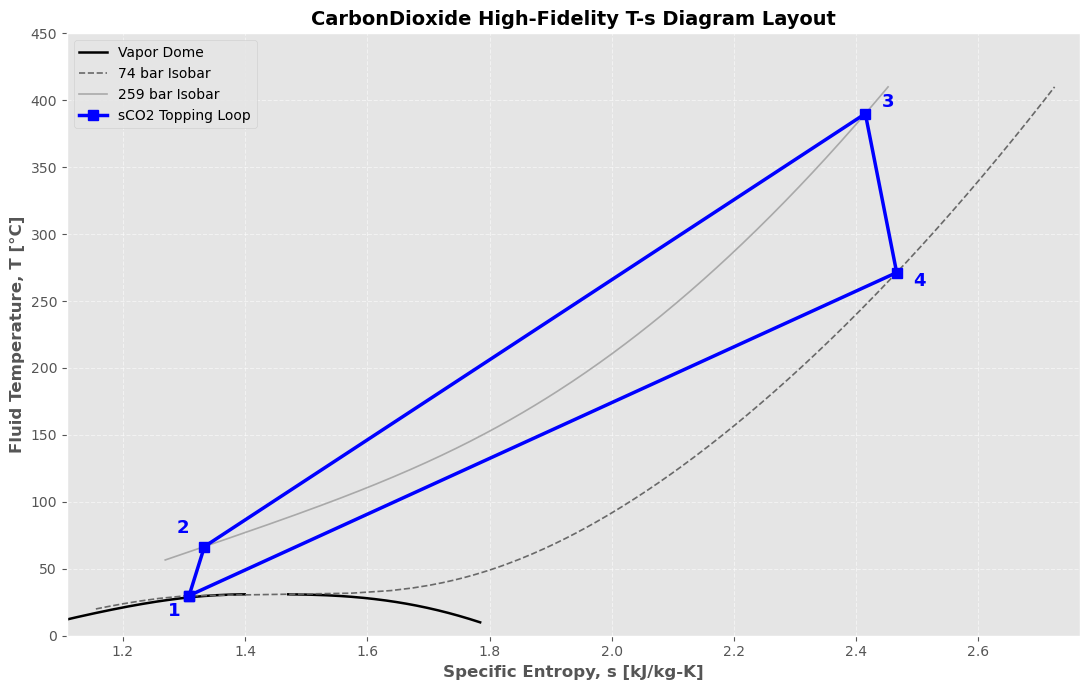

     SCBC FIELD CONVERGENCE PERFORMANCE SUMMARY   
Working Fluid Selection        : sCO2 (CarbonDioxide)
Topping Fluid Mass Flow Rate   : 16.607 kg/s
--------------------------------------------------
Turbine Power Output (W_dot_BCT): 1812.69 kW
Pump Power Consumption (W_dot_BCC): 562.69 kW
Net System Power Output Target : 1250.00 kW
--------------------------------------------------
Evaporator Heat Input (Q_in)   : 8350.72 kW
Final Optimized Topping Ene Efficiency: 14.97 %


In [8]:
# =============================================================================
# 4. ACADEMIC GRAPHICS VISUALIZATION GENERATOR
# =============================================================================
# Setup cycle drawing vectors (closed loop 1->2->3->4->1)
T_cycle = np.array([T1, T2, T3, T4, T1]) - 273.15
s_cycle = np.array([s1, s2, s3, s4, s1]) / 1000.0

T_crit = CP.PropsSI('TCRIT', fluid)
T_min_plot = max(10.0 + 273.15, CP.PropsSI('TTRIPLE', fluid) + 5.0)

# Generate stable Vapor Dome boundaries
T_sat = np.linspace(T_min_plot, T_crit - 0.05, 150)
s_liq = np.array([CP.PropsSI('S', 'T', t, 'Q', 0, fluid) for t in T_sat]) / 1000.0
s_vap = np.array([CP.PropsSI('S', 'T', t, 'Q', 1, fluid) for t in T_sat]) / 1000.0

# Generate safe isobar tracking paths (prevent subcooled lookup boundary crashes)
T_iso_low  = np.linspace(T1 - 10, T3 + 20, 200)
T_iso_high = np.linspace(T2 - 10, T3 + 20, 200)

s_iso_low  = np.array([CP.PropsSI('S', 'T', t, 'P', P1, fluid) for t in T_iso_low]) / 1000.0
s_iso_high = np.array([CP.PropsSI('S', 'T', t, 'P', P3, fluid) for t in T_iso_high]) / 1000.0

# Render graphic panel
plt.figure(figsize=(11, 7))
plt.plot(s_liq, T_sat - 273.15, 'k-', linewidth=1.8, label='Vapor Dome')
plt.plot(s_vap, T_sat - 273.15, 'k-', linewidth=1.8)

plt.plot(s_iso_low, T_iso_low - 273.15, '--', color='dimgray', linewidth=1.2, label=f'{P1_bar:.0f} bar Isobar')
plt.plot(s_iso_high, T_iso_high - 273.15, '-', color='darkgray', linewidth=1.2, label=f'{P3_bar:.0f} bar Isobar')
plt.plot(s_cycle, T_cycle, 'b-s', linewidth=2.5, markersize=7, label='sCO2 Topping Loop')

# Format markers
offsets = [(-15, -15), (-20, 10), (12, 5), (12, -10)]
for idx, label in enumerate(['1', '2', '3', '4']):
    plt.annotate(label, (s_cycle[idx], T_cycle[idx]), textcoords="offset points", 
                 xytext=offsets[idx], fontsize=13, color='blue', fontweight='bold')

plt.title(f'{fluid} High-Fidelity T-s Diagram Layout', fontweight='bold', fontsize=14)
plt.xlabel('Specific Entropy, s [kJ/kg-K]', fontweight='bold', fontsize=12)
plt.ylabel('Fluid Temperature, T [°C]', fontweight='bold', fontsize=12)
plt.xlim([s_cycle.min() - 0.2, s_cycle.max() + 0.3])
plt.ylim([0.0, 450.0])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# =============================================================================
# 5. COMPREHENSIVE REPRODUCIBILITY KEY RESULTS REPORT
# =============================================================================
print(f"==================================================")
print(f"     SCBC FIELD CONVERGENCE PERFORMANCE SUMMARY   ")
print(f"==================================================")
print(f"Working Fluid Selection        : sCO2 ({fluid})")
print(f"Topping Fluid Mass Flow Rate   : {m_dot_BC:.3f} kg/s")
print(f"--------------------------------------------------")
print(f"Turbine Power Output (W_dot_BCT): {W_dot_BCT_kW:.2f} kW")
print(f"Pump Power Consumption (W_dot_BCC): {W_dot_BCC_kW:.2f} kW")
print(f"Net System Power Output Target : {W_dot_BC_target/1000.0:.2f} kW")
print(f"--------------------------------------------------")
print(f"Evaporator Heat Input (Q_in)   : {Q_dot_in_BC_kW:.2f} kW")
print(f"Final Optimized Topping Ene Efficiency: {Eta_en_BC * 100:.2f} %")
print(f"==================================================")